# *Práctica de Laboratorio Nro. 009: Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
###Arlette Quezada
###Roy Gordillo
###Eduardo Soto
###Danny Beltran
###Pablo Pineda

###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 28 de mayo de 2026


##**Tarea 1: Prueba de Hipótesis para Dos Muestras Independientes (A/B Testing)**
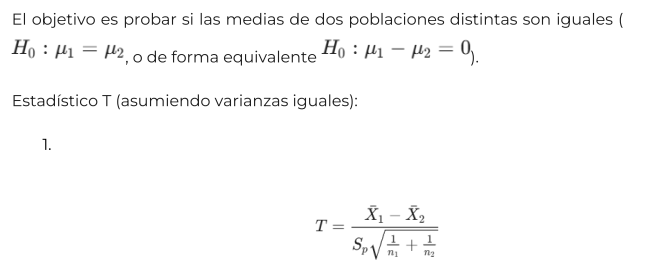


2. **Escenario: Usted es ingeniero de software y desea saber si el
"Algoritmo A" consume menos memoria RAM que el "Algoritmo B".
Ejecuta ambos en entornos aislados y registra el consumo en MB.**

--- A/B Testing: Algoritmo A vs Algoritmo B ---
Media Algo A: 118.91 MB
Media Algo B: 126.71 MB
Estadístico T: -2.5362
Valor-p: 1.3347e-02
Conclusión: Se RECHAZA H0.
Existe una diferencia significativa en el consumo de memoria.


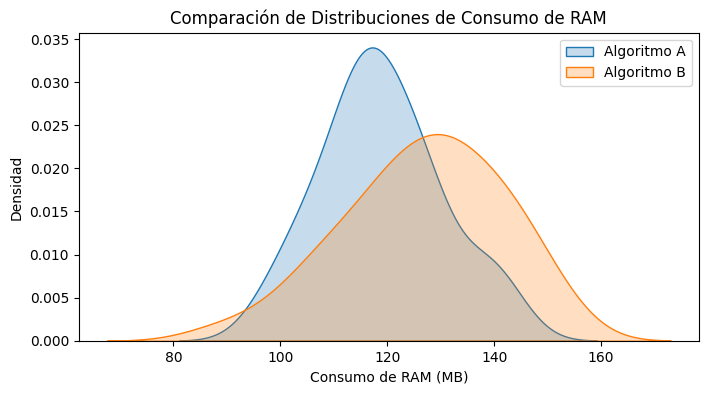

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =====================================================
# Datos empíricos (Consumo de RAM en MB)
# =====================================================

np.random.seed(42)

memoria_algo_A = np.random.normal(loc=120.5, scale=12.0, size=35)
memoria_algo_B = np.random.normal(loc=128.2, scale=15.0, size=40)

alpha = 0.05

# =====================================================
# Prueba T para muestras independientes (2 colas)
# =====================================================

stat_ind, p_val_ind = ttest_ind(
    memoria_algo_A,
    memoria_algo_B,
    equal_var=True
)

print("--- A/B Testing: Algoritmo A vs Algoritmo B ---")
print(f"Media Algo A: {np.mean(memoria_algo_A):.2f} MB")
print(f"Media Algo B: {np.mean(memoria_algo_B):.2f} MB")
print(f"Estadístico T: {stat_ind:.4f}")
print(f"Valor-p: {p_val_ind:.4e}")

if p_val_ind < alpha:
    print("Conclusión: Se RECHAZA H0.")
    print("Existe una diferencia significativa en el consumo de memoria.")
else:
    print("Conclusión: NO se rechaza H0.")
    print("No hay evidencia de que los algoritmos difieran en consumo.")

# =====================================================
# Visualización
# =====================================================

plt.figure(figsize=(8, 4))

sns.kdeplot(memoria_algo_A, fill=True, label="Algoritmo A")
sns.kdeplot(memoria_algo_B, fill=True, label="Algoritmo B")

plt.title("Comparación de Distribuciones de Consumo de RAM")
plt.xlabel("Consumo de RAM (MB)")
plt.ylabel("Densidad")
plt.legend()

plt.show()


# **Tarea 2: Prueba de Hipótesis para Muestras Pareadas (Dependientes)**

Se usa cuando los datos de ambos grupos provienen de las mismas unidades de observación (ej. métricas del sistema "Antes" y "Después" de aplicar un parche de optimización). Aquí se evalúa la media de las diferencias      $d_{i}=X_{2i}-X_{1i}$.  

$$T=\frac{\bar{d}-\mu_{d}}{S_{d}/\sqrt{n}}$$  
**Escenario**: Usted mide el tiempo de latencia de 15 servidores específicos antes y después de instalar un nuevo firewall.  
**Implemente y analice el código** con ttest_rel:

In [ ]:
import numpy as np
from scipy.stats import ttest_rel

# Latencia en ms (las posiciones en los arrays corresponden al mismo servidor)
latencia_antes = np.array([45, 52, 48, 55, 60, 42, 49, 58, 51, 46, 50, 47, 53, 59, 44])
latencia_despues = np.array([41, 50, 45, 50, 56, 40, 46, 53, 48, 42, 47, 45, 51, 55, 40])

# Prueba pareada (H1: la latencia "después" es menor, por tanto (antes - despues) > 0)
# Para evaluar si "después" bajó, usamos una prueba de cola superior sobre las diferencias (antes - despues)
# SciPy modernos permiten alternative='greater' en ttest_rel
stat_rel, p_val_rel = ttest_rel(latencia_antes, latencia_despues, alternative='greater')

print("\n--- Análisis Pareado: Impacto del Nuevo Firewall ---")
print(f"Media Diferencias (Antes - Después): {np.mean(latencia_antes - latencia_despues):.2f} ms")
print(f"Estadístico T Pareado: {stat_rel:.4f}")
print(f"Valor-p (1 cola): {p_val_rel:.4e}")

if p_val_rel < 0.05:
    print("Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.")
else:
    print("Conclusión: NO se rechaza H0. El firewall no mejoró la latencia.")


--- Análisis Pareado: Impacto del Nuevo Firewall ---
Media Diferencias (Antes - Después): 3.33 ms
Estadístico T Pareado: 12.3359
Valor-p (1 cola): 3.2787e-09
Conclusión: Se RECHAZA H0. El firewall redujo significativamente la latencia.


<div align="center">
  📁 <a href="./APE.md">APE GENERAL</a>
</div>